In [1]:
import animate as an
import makelines as ml
import numpy as np
from matplotlib import pyplot as plt
import timeit
from IPython.display import Video,display
import networkx as nx
import os
import pickle
import torch
import multiprocess as mp
mp.set_start_method('spawn')

In three dimensions, it seems that frozen spirals only seem to appear often below the Benjamin Feir line $bc<1$. This may be because of instabilities of the spiral cores with perturbation wavevector along the length of the defect line, as we seem to see helical oscillations appear in simulations.

Plot the final state faces for running or complete simulations

./rdcu -s 1 -t 1900.000000 -d 10.000000,0.001000,0,0.100000 -N 128,128,128 -L 200.000000,200.000000,200.000000 -s 100 -n 2 -D1 -R scratch/3dcgle/9/1/ 

0.095	5.372e+02	5.130e+03	0.100000	1807	

b=1.750000, c=0.444444
final time: 180.000000


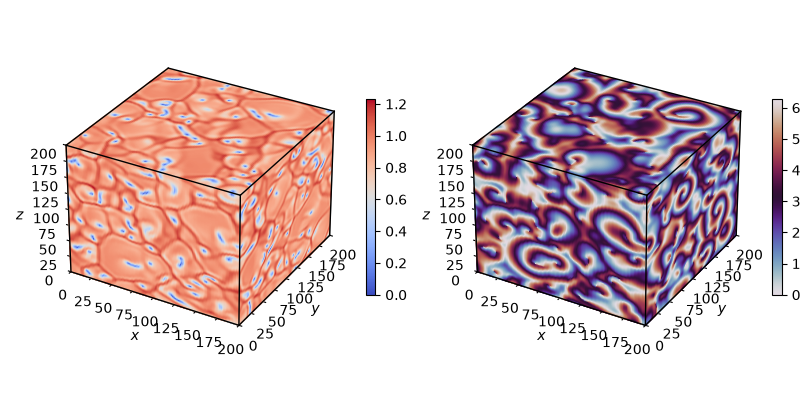

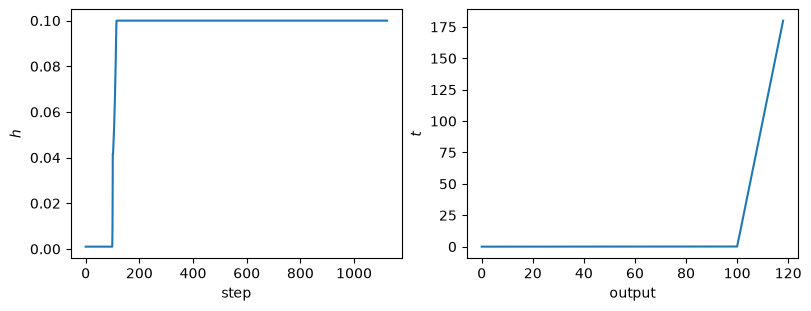

In [57]:
Ns=np.array([128,128,128])
Ls=np.array([200.,200.,200.])
N=np.prod(Ns)

filebase='scratch/3dcgle/9/1/'

file=open('%s.out'%(filebase),'r')
sts=file.readlines()
file.close()
print(sts[0])
print(sts[-1])
file=open('%scoupling.dat'%(filebase),'r')
sts=file.readlines()
file.close()
b=-float(sts[5].split(',')[0])
c=float(sts[18].split(',')[0])
print('b=%f, c=%f'%(b,c))
ys=np.fromfile('%sfs.dat'%(filebase),dtype=float)[:2*N].reshape([2]+Ns.tolist())
ts=np.fromfile('%stimes.dat'%(filebase),dtype=float)
hs=np.fromfile('%ssteps.dat'%(filebase),dtype=float)

print("final time: %f"%(ts[-1]))
faces=[[ys[:,0,:,:],ys[:,:,0,:],ys[:,:,:,0],ys[:,-1,:,:],ys[:,:,-1,:],ys[:,:,:,-1]]]
Rmax=np.max(np.linalg.norm(faces,axis=2))
lines=None
n=0

an.makeplot(n, Ns, Ls, faces=faces, lines=lines, Rmax=Rmax, show=True, save=False)

ts=np.fromfile('%stimes.dat'%(filebase),dtype=float)
hs=np.fromfile('%ssteps.dat'%(filebase),dtype=float)

plt.subplots(1,2,figsize=(8,3),layout='constrained')
plt.subplot(1,2,1)
plt.plot(hs)
# plt.yscale('log')
plt.xlabel('step')
plt.ylabel(r'$h$')
plt.subplot(1,2,2)
plt.plot(ts)
plt.xlabel('output')
plt.ylabel(r'$t$')
plt.show()

Make and plot the final state lines for running or complete simulations

savelines 0
2.1078414861112833


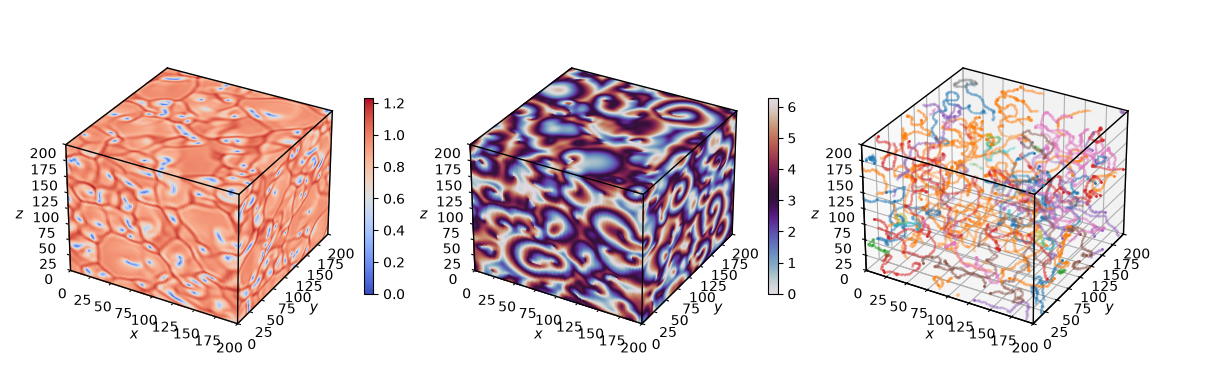

14.579740819055587


In [58]:
device='cuda'
chunk=2048

start=timeit.default_timer()
line=ml.savelines(0,'%sfs.dat'%(filebase),Ns,Ls,0,chunk,device)
stop=timeit.default_timer()
print(stop-start)

start=timeit.default_timer()
an.makeplot(0, Ns, Ls, faces=faces, lines=[line], cids=[[i%len(an.colors) for i in range(len(line))]], Rmax=Rmax, show=True, save=False)
stop=timeit.default_timer()
print(stop-start)

load the saved lines for complete simulations

In [47]:
file=open('%slines.dat'%filebase, 'rb')
lines=pickle.load(file)
file.close()

file=open('%sdiffs.dat'%filebase, 'rb')
diffs=pickle.load(file)
file.close()

file=open('%slineids.dat'%filebase, 'rb')
ids,cids,edges=pickle.load(file)
file.close()
nt=len(lines)

plot the ancestry graph

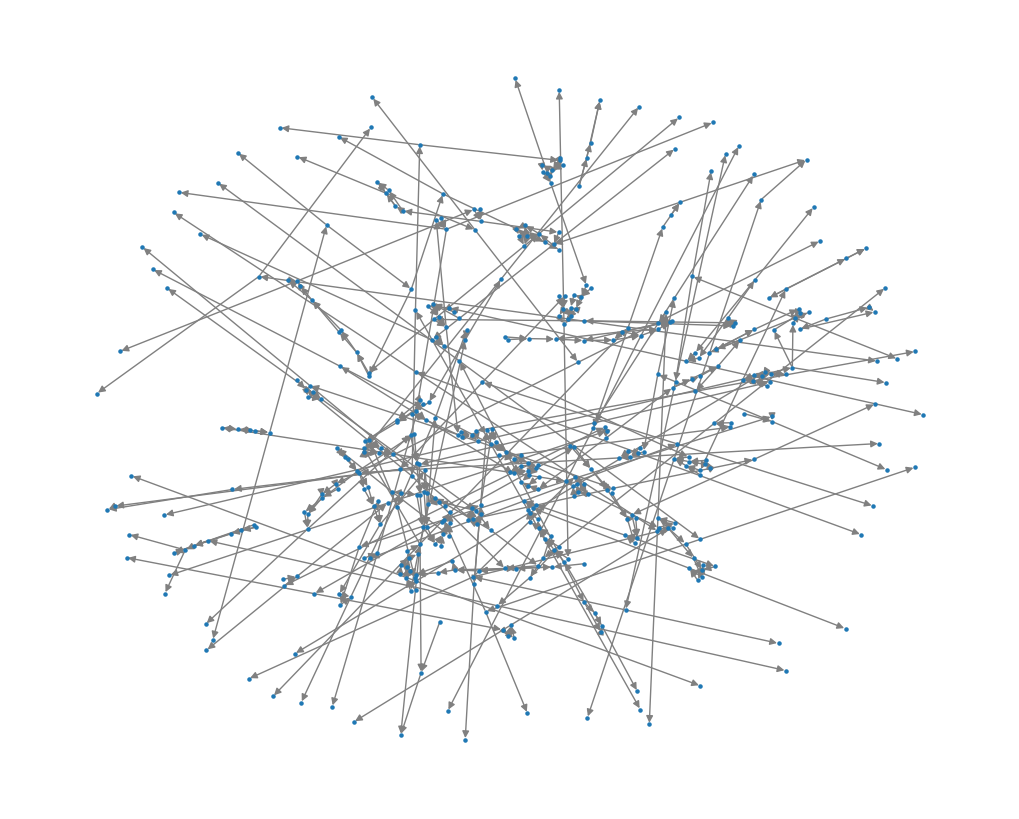

In [48]:
G=nx.DiGraph(edges)
plt.figure(figsize=(10, 8))
nx.draw(G,node_size=5,edge_color='gray')
plt.show()

plot the line ancestry as a directed acyclic graph

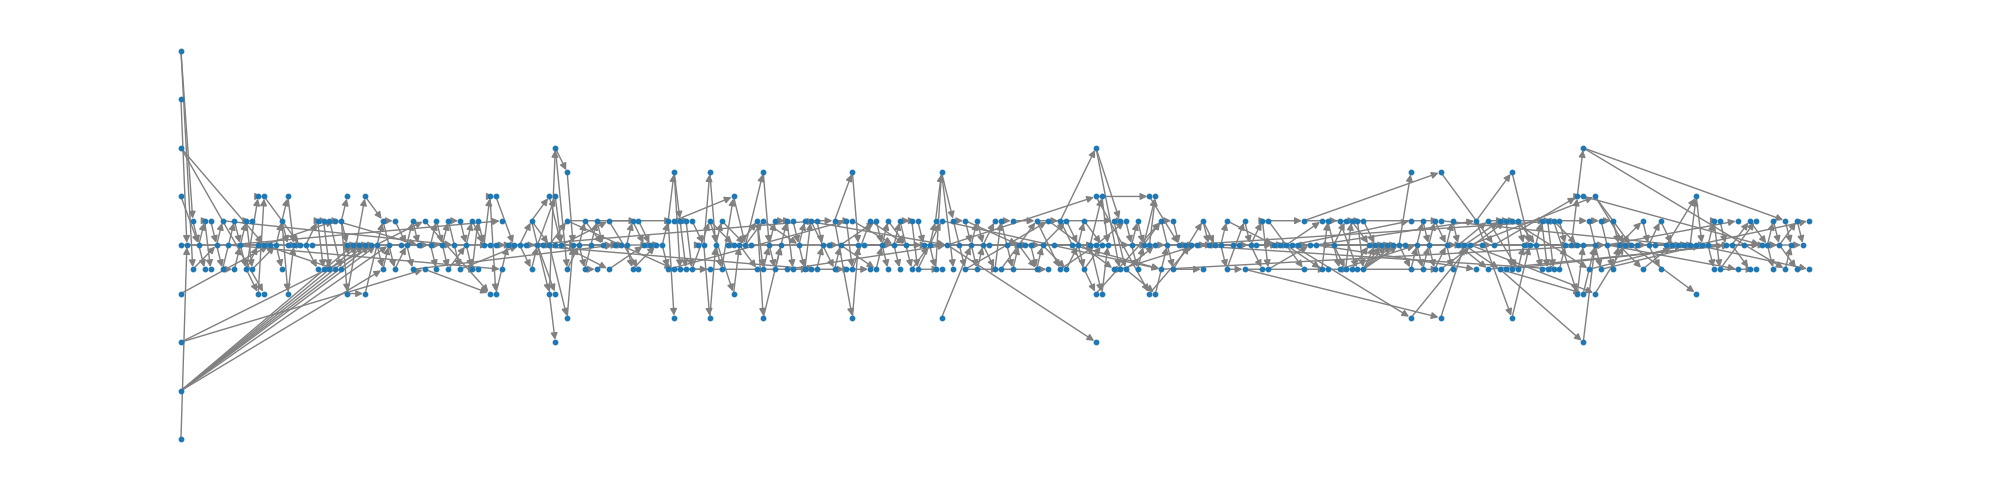

In [49]:
G=nx.DiGraph(edges)

for node in G.nodes:
    for n in range(len(lines)):
        if len(np.where(ids[n]==node)[0])>0:
            break
    G.nodes[node]["birth"] = n

pos = nx.multipartite_layout(G, subset_key="birth", align='vertical')
for key in pos.keys():
    oldval=pos[key]
    newval=np.array([oldval[0],-oldval[1]])
    pos[key]=newval
    
plt.figure(figsize=(20, 5))
nx.draw_networkx(G,pos=pos,with_labels=False,edge_color='gray',node_size=10)

plt.axis("off")
plt.tight_layout()
plt.show()

plot the lines

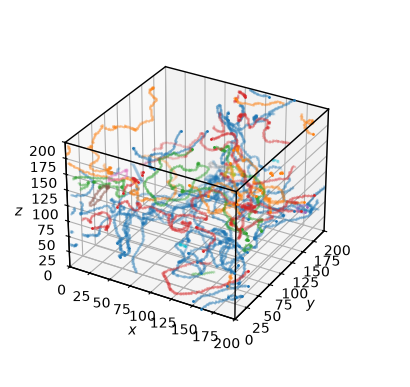

7.836597057059407


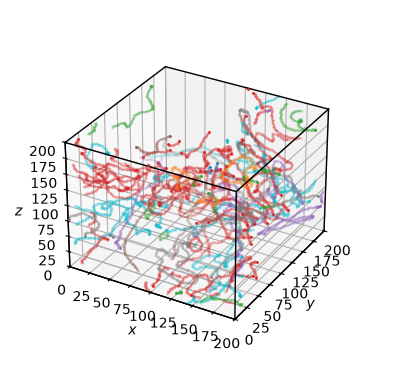

8.761079367250204


In [50]:
faces=None

start=timeit.default_timer()
an.makeplot(0, Ns, Ls, faces=None, lines=lines, cids=cids, show=True, save=False)
stop=timeit.default_timer()
print(stop-start)

start=timeit.default_timer()
an.makeplot(nt-1, Ns, Ls, faces=None, lines=lines, cids=cids, show=True, save=False)
stop=timeit.default_timer()
print(stop-start)

look at a step where the longest line changed

In [51]:
file=open(filebase+'diffs.dat','rb')
diffs=pickle.load(file)
file.close()

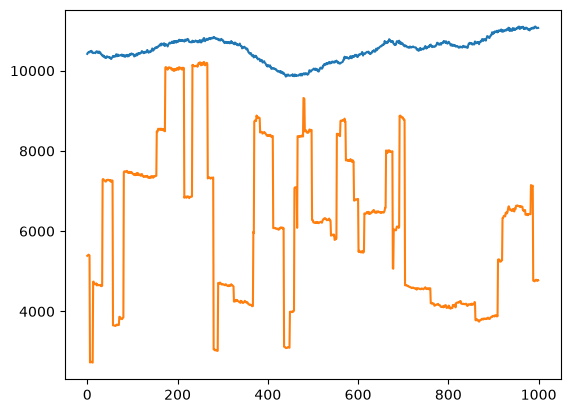

In [52]:
plt.plot([np.sum([len(l) for l in ls]) for ls in lines])
plt.plot([np.max([len(l) for l in ls]) for ls in lines])

In [53]:
n=np.where(np.abs(np.diff([np.max([len(l) for l in ls]) for ls in lines]))>500)[0][0]
ls=np.array([len(l) for l in lines[n]])
order=np.argsort(ls)
print(ls[order[-2:]])
print(order[-2:])
print(diffs[n][order[-2:]])

[2032 5397]
[3 0]
[[ 6  7  0  6 65 10  6 58  7 55 29 24 30]
 [ 0  7  7  6 20  9 20 30 13  6  6 37 14]]


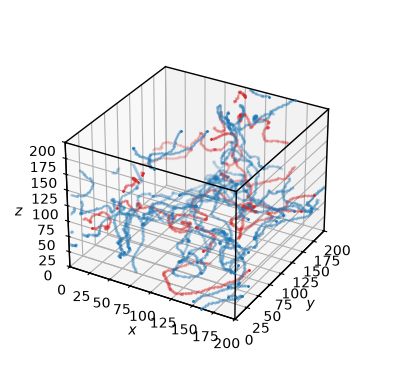

5.968342660926282


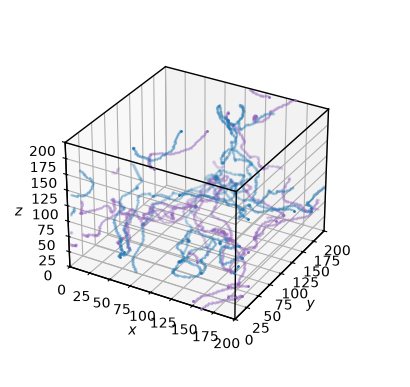

4.25758896721527


In [54]:
start=timeit.default_timer()
ls=np.array([len(l) for l in lines[n]])
order=np.argsort(ls)
an.makeplot(0, Ns, Ls, faces=None, lines=[[lines[n][order[-2]],lines[n][order[-1]]]], cids=[cids[n][order[-2:]]], show=True, save=False)
stop=timeit.default_timer()
print(stop-start)

start=timeit.default_timer()
ls=np.array([len(l) for l in lines[n+1]])
order=np.argsort(ls)
an.makeplot(0, Ns, Ls, faces=None, lines=[[lines[n+1][order[-2]],lines[n+1][order[-1]]]], cids=[cids[n+1][order[-2:]]], show=True, save=False)
stop=timeit.default_timer()
print(stop-start)

plot the lines alongside the saved faces of the fields

In [55]:
file=open("%sfaces.dat"%(filebase),"rb")
faces=pickle.load(file)
file.close()
Rmax=np.max(faces)

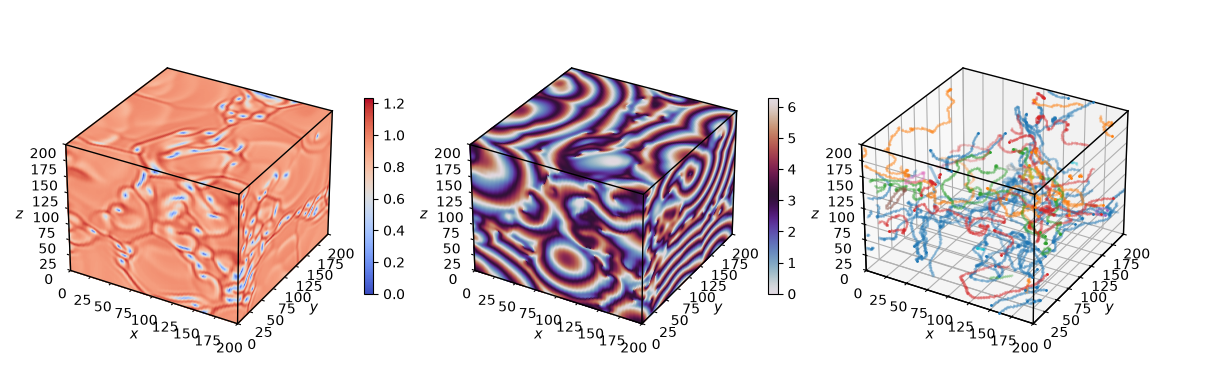

10.80292883887887


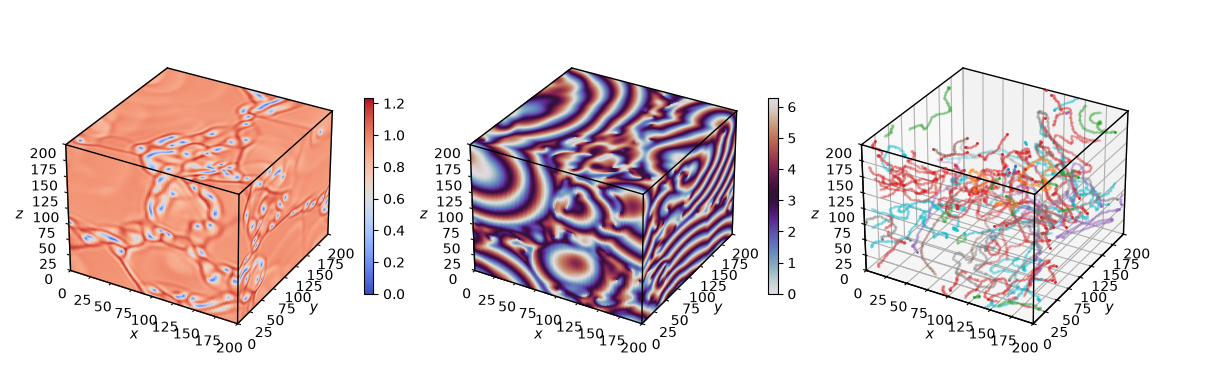

11.760216910857707


In [56]:
start=timeit.default_timer()
an.makeplot(0, Ns, Ls, faces, lines, cids, Rmax, show=True, save=False)
stop=timeit.default_timer()
print(stop-start)

start=timeit.default_timer()
an.makeplot(nt-1, Ns, Ls, faces, lines, cids, Rmax, show=True, save=False)
stop=timeit.default_timer()
print(stop-start)

In [40]:
if os.path.exists('%sanimation.mp4'%(filebase)):
    display(Video('%sanimation.mp4'%(filebase)))